<div style="font-size:9pt;">

2) Environment and Acceleration Model Settings

Use the following settings for the environment:

- JUICE drag coefficient: \( C_D = 1.2 \)
- JUICE reference area (drag): \( 100 \ \text{m}^2 \)
- JUICE radiation pressure coefficient: \( C_r = 1.2 \)
- JUICE reference area (radiation): \( 100 \ \text{m}^2 \)
- JUICE mass: \( 2 \cdot 10^3 \ \text{kg} \)

- Ganymede exponential atmosphere:
  - \( \rho_0 = 2 \cdot 10^{-9} \ \text{kg m}^{-3} \)
  - Scale height \( H = 40 \ \text{km} \)

- Default settings for all other relevant bodies.

---

Define the following acceleration models acting on JUICE:

- Spherical harmonic gravity of Ganymede, up to degree and order 2
- Spherical harmonic gravity of Jupiter, up to degree 4 and order 0
- Point mass gravity from:
  - Sun
  - Saturn
  - Europa
  - Io
  - Callisto

- Cannonball radiation pressure from the Sun, including shadowing by Ganymede
- Aerodynamic force due to Ganymede’s exosphere

---

Where necessary, extend the settings for the environment to allow these accelerations to be set up.

Use the same integrator and propagator settings as in Question 1.

</div>


<small>Importing Modules</small>

In [ ]:
import os

import numpy as np
from IPython.core.pylabtools import figsize
from PIL.ImageColor import colormap
from astropy.coordinates.matrix_utilities import rotation_matrix
from matplotlib import pyplot as plt
from matplotlib.pyplot import subplots
from matplotlib import rcParams
from scipy.constants import mu_0
from tudatpy import constants
from tudatpy.data import save2txt
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion

In [118]:
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 10
rcParams['axes.labelsize'] = 10
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8
rcParams['legend.fontsize'] = 9
plt.rcParams["mathtext.fontset"] = "stix"

In [4]:
palette = {
    "pastel_blue"   : "#6AA7FF",
    "pastel_pink"   : "#FF82A9",
    "pastel_green"  : "#7ED6A6",
    "pastel_purple" : "#A894E8",
    "pastel_orange" : "#FFB27C",
    "pastel_teal"   : "#63D2C6"
}

In [5]:
# Retrieve current directory
current_directory = os.getcwd()

# student number: 1244779 --> 1244ABC
A = 4
B = 2
C = 6

In [6]:
simulation_start_epoch = (
    35.4 * constants.JULIAN_YEAR
    + A * 7.0 * constants.JULIAN_DAY
    + B * constants.JULIAN_DAY
    + C * constants.JULIAN_DAY / 24.0
)
simulation_end_epoch = simulation_start_epoch + 344.0 * constants.JULIAN_DAY / 24.0


<small>Create Environment</small>

In [7]:
# Load spice kernels.
spice.load_standard_kernels()
spice.load_kernel(current_directory + "/juice_mat_crema_5_1_150lb_v01.bsp")

# Create settings for celestial bodies
bodies_to_create = ["Ganymede", "Jupiter", "Sun", "Saturn", "Europa", "Io", "Callisto"]
global_frame_origin = "Ganymede"
global_frame_orientation = "ECLIPJ2000"
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

<small> Create Accelerations </small>

In [8]:
reference_area = 100.0                                  # m2
drag_coefficient = 1.2
radiation_pressure_coefficient = 1.2                    # kg
density_scale_height = 40e3                             # m
density_at_zero_alt = 2e-9                              # kg/m3

<small> Create Vehicle </small>

In [9]:
body_settings.add_empty_settings("JUICE")

body_settings.get("Ganymede").atmosphere_settings = environment_setup.atmosphere.exponential(density_at_zero_alt, density_scale_height)

# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)
bodies.get_body('JUICE').mass = 2000.0

aero_coefficient_settings = environment_setup.aerodynamic_coefficients.constant(reference_area,[drag_coefficient,0.0,0.0])

environment_setup.add_aerodynamic_coefficient_interface(bodies, "JUICE", aero_coefficient_settings)

occulting_bodies = ["Ganymede"]
radiation_pressure_settings = environment_setup.radiation_pressure.cannonball("Sun", reference_area, radiation_pressure_coefficient, occulting_bodies)

environment_setup.add_radiation_pressure_interface(bodies, "JUICE", radiation_pressure_settings)


In [10]:
# Define bodies that are propagated, and their central bodies of propagation.
bodies_to_propagate = ["JUICE"]
central_bodies = ["Ganymede"]



# Define accelerations acting on vehicle.
acceleration_settings_on_vehicle = dict(
    Ganymede =
    [
    propagation_setup.acceleration.spherical_harmonic_gravity(2,2),
    propagation_setup.acceleration.aerodynamic()
    ],

    Jupiter =
    [
    propagation_setup.acceleration.spherical_harmonic_gravity(4,0)
    ],

    Sun =
    [
    propagation_setup.acceleration.point_mass_gravity(),
    propagation_setup.acceleration.cannonball_radiation_pressure()
    ],

    Saturn =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Europa =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Io =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ],

    Callisto =
    [
    propagation_setup.acceleration.point_mass_gravity()
    ]
)

# Create global acceleration dictionary.
acceleration_settings = {"JUICE": acceleration_settings_on_vehicle}

# Create acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

<small> Create Propagation Settings </small>

In [11]:
# Define initial state.
system_initial_state = spice.get_body_cartesian_state_at_epoch(
    target_body_name="JUICE",
    observer_body_name="Ganymede",
    reference_frame_name="ECLIPJ2000",
    aberration_corrections="NONE",
    ephemeris_time=simulation_start_epoch,
)

# Define required outputs
# As required by the question dep variable saved in the order: [keplerian elements (6),
#                                                               gravitational acceleration on JUICE due to Ganymede using spherical harmonic gravity (3),
#                                                               gravitational acceleration on JUICE due to Io using point-mass gravity (3),
#                                                               gravitational acceleration on JUICE due to the Sun using point-mass gravity (3),
#                                                               aerodynamic acceleration on JUICE due to Ganymede’s (3),
#                                                               solar radiation pressure acceleration on JUICE due to the Sun - cannonball model, with shadowing by Ganymede (3)]
# Total Variables: 21

dependent_variables_to_save = [

    propagation_setup.dependent_variable.keplerian_state("JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.spherical_harmonic_gravity_type,"JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.point_mass_gravity_type,"JUICE", "Io"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.point_mass_gravity_type,"JUICE", "Sun"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.aerodynamic_type,"JUICE", "Ganymede"),

    propagation_setup.dependent_variable.single_acceleration(propagation_setup.acceleration.cannonball_radiation_pressure_type,"JUICE", "Sun"),


]

# Create numerical integrator settings.
fixed_step_size = 10.0
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, coefficient_set=propagation_setup.integrator.CoefficientSets.rk_4
)

# Create propagation settings.
termination_settings = propagation_setup.propagator.time_termination(
    simulation_end_epoch
)
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings,
    output_variables=dependent_variables_to_save,
)

propagator_settings.print_settings.print_initial_and_final_conditions = True

<small> Propagate Orbit </small>

In [12]:
# Create simulation object and propagate dynamics.
dynamics_simulator = simulator.create_dynamics_simulator(
    bodies, propagator_settings
)

# Retrieve all data produced by simulation
propagation_results = dynamics_simulator.propagation_results

# Extract numerical solution for states and dependent variables
state_history = propagation_results.state_history
dependent_variables = propagation_results.dependent_variable_history



<small> Save Results </small>

In [13]:
save2txt(
    solution = state_history, filename="JUICEPropagationHistory_Q1.dat", directory="./"
)

save2txt(
    solution=dependent_variables,
    filename="JUICEPropagationHistory_DependentVariables_Q1.dat",
    directory="./",
)

<small>Extracting Results</small>

In [14]:
# Extract dep variableS --> saved in the order: [keplerian elements (6),
#                                                               gravitational acceleration on JUICE due to Ganymede using spherical harmonic gravity (3),
#                                                               gravitational acceleration on JUICE due to Io using point-mass gravity (3),
#                                                               gravitational acceleration on JUICE due to the Sun using point-mass gravity (3),
#                                                               aerodynamic acceleration on JUICE due to Ganymede (3),
#                                                               solar radiation pressure acceleration on JUICE due to the Sun - cannonball model, with shadowing by Ganymede (3)]

result = np.vstack(list(dependent_variables.values()))

keplerian_elements_JUICE = result[:, 0:6]
grav_acc_JUICE_Ganymede = result[:, 6:9]
grav_acc_JUICE_Io = result[:, 9:12]
grav_acc_JUICE_Sun = result[:, 12:15]
aero_acc_JUICE_Ganymede = result[:, 15:18]
srp_acc_JUICE_Sun = result[:, 18:21]

time = dependent_variables.keys()
time_days = [
    t / constants.JULIAN_DAY - simulation_start_epoch / constants.JULIAN_DAY
    for t in time
]

<small> Most accelerations will exhibit (quasi-)periodic variations with dif
ferent periods. For this question, you will investigate this time
variability in the accelerations acting on JUICE in your simulation. <br>

i. Plot the norms of the Ganymede-centered gravitational accelera
tion, acting on JUICE, exerted by the Sun and Io, respectively.</small>

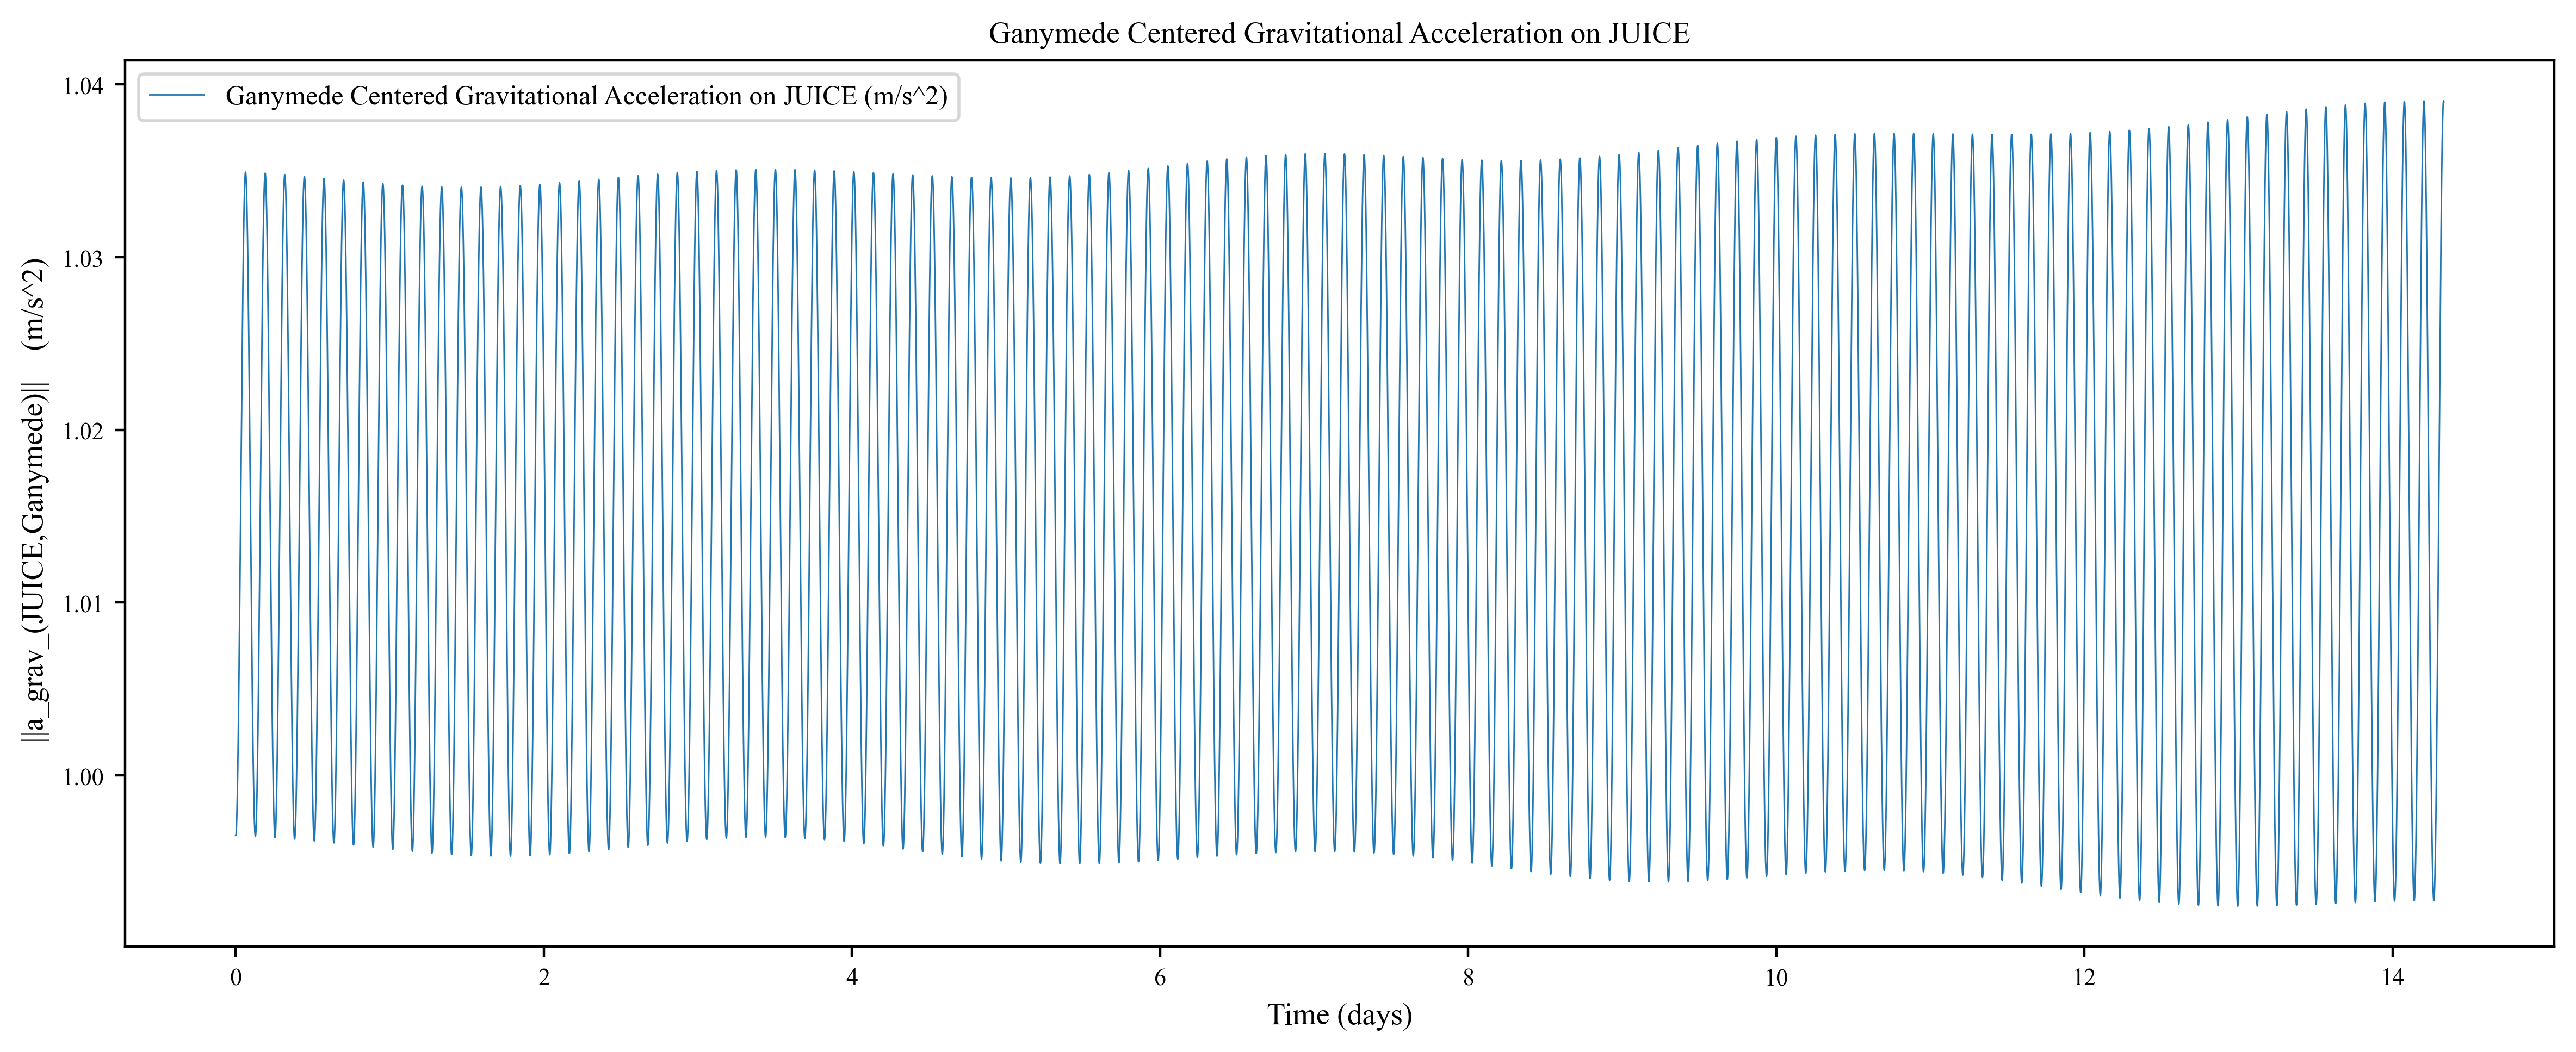

In [15]:
# Plot
plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Ganymede, axis = 1), label = "Ganymede Centered Gravitational Acceleration on JUICE (m/s^2)", linewidth = 0.5)
plt.xlabel("Time (days)")
plt.ylabel(" ||a_grav_(JUICE,Ganymede)||    (m/s^2)")
plt.legend()
plt.title("Ganymede Centered Gravitational Acceleration on JUICE")
plt.tight_layout()
plt.show()

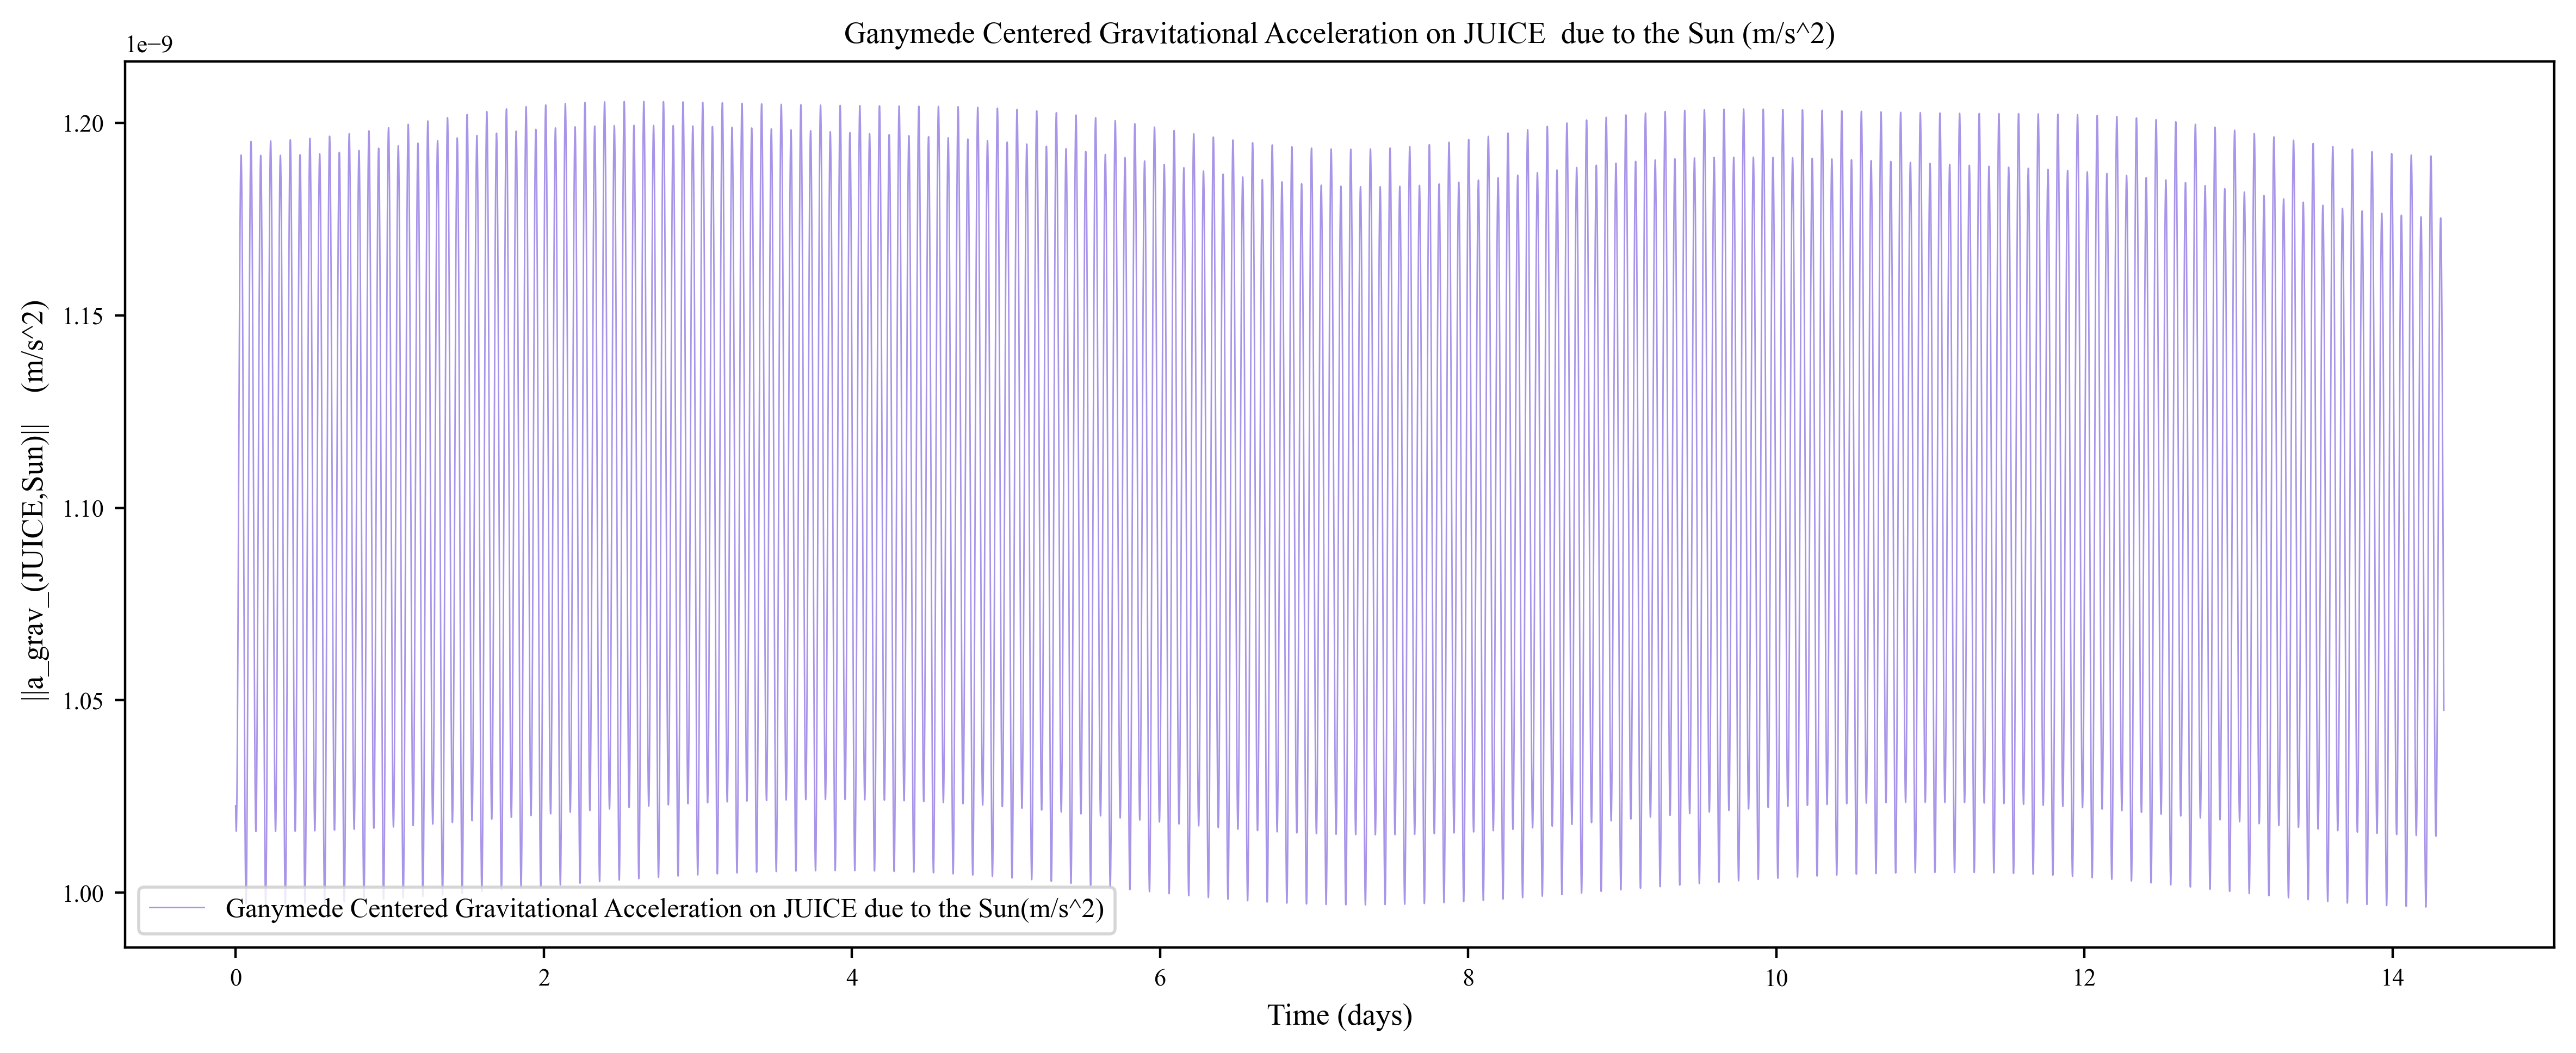

In [31]:
# Plot
plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Sun, axis = 1), label = "Ganymede Centered Gravitational Acceleration on JUICE due to the Sun(m/s^2)", linewidth = 0.5, color = palette['pastel_purple'])
plt.xlabel("Time (days)")
plt.ylabel(" ||a_grav_(JUICE,Sun)||    (m/s^2)")
plt.legend()
plt.title("Ganymede Centered Gravitational Acceleration on JUICE  due to the Sun (m/s^2)")
plt.tight_layout()
plt.show()

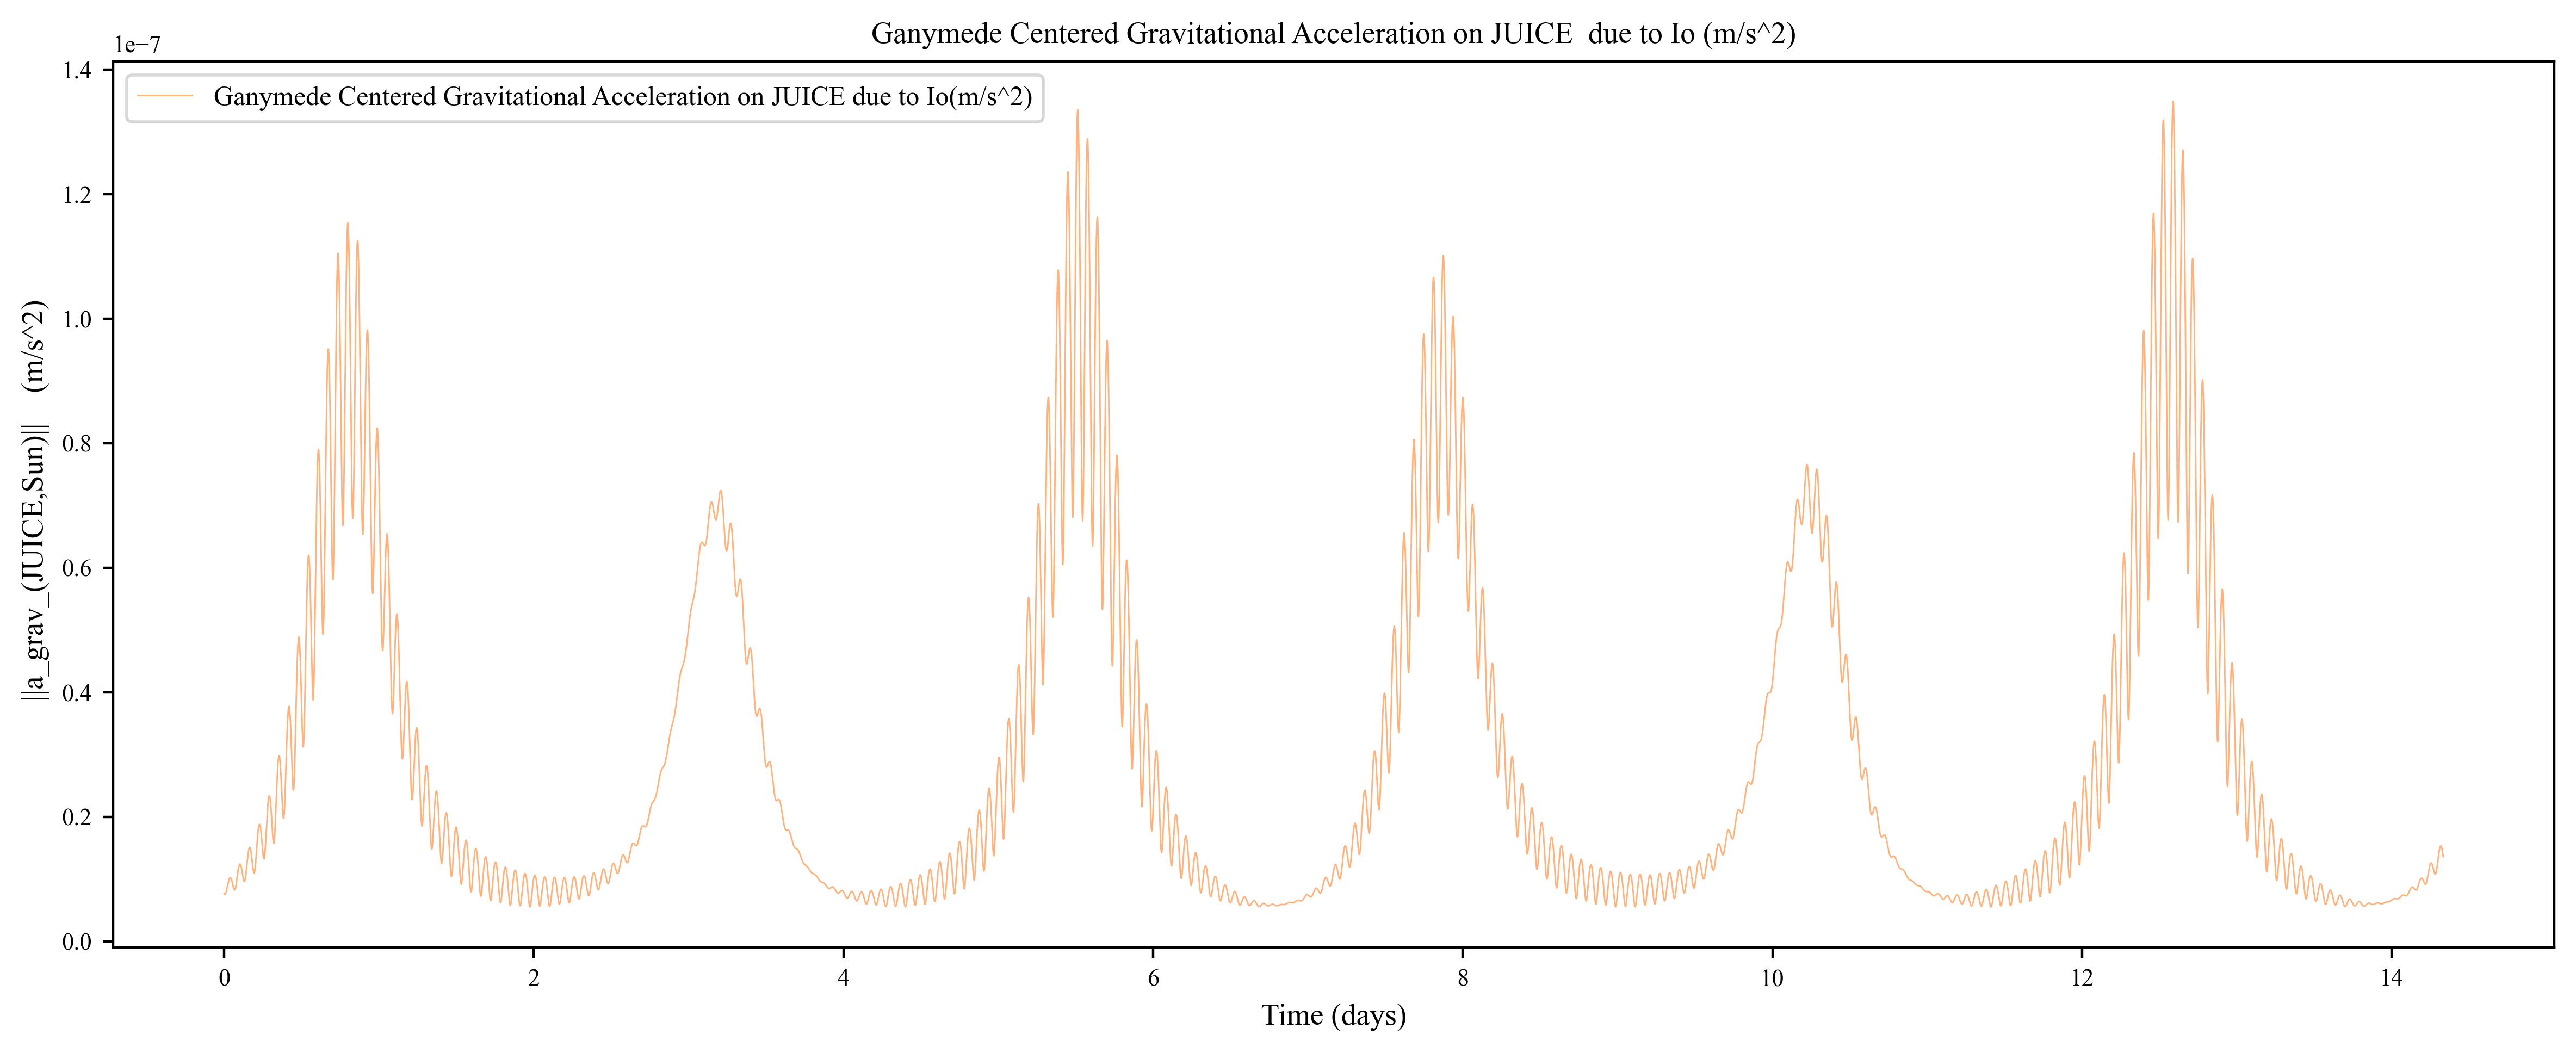

In [17]:
# Plot
plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Io, axis = 1), label = "Ganymede Centered Gravitational Acceleration on JUICE due to Io(m/s^2)", linewidth = 0.5, color = palette['pastel_orange'])
plt.xlabel("Time (days)")
plt.ylabel(" ||a_grav_(JUICE,Sun)||    (m/s^2)")
plt.legend()
plt.title("Ganymede Centered Gravitational Acceleration on JUICE  due to Io (m/s^2)")
plt.tight_layout()
plt.show()

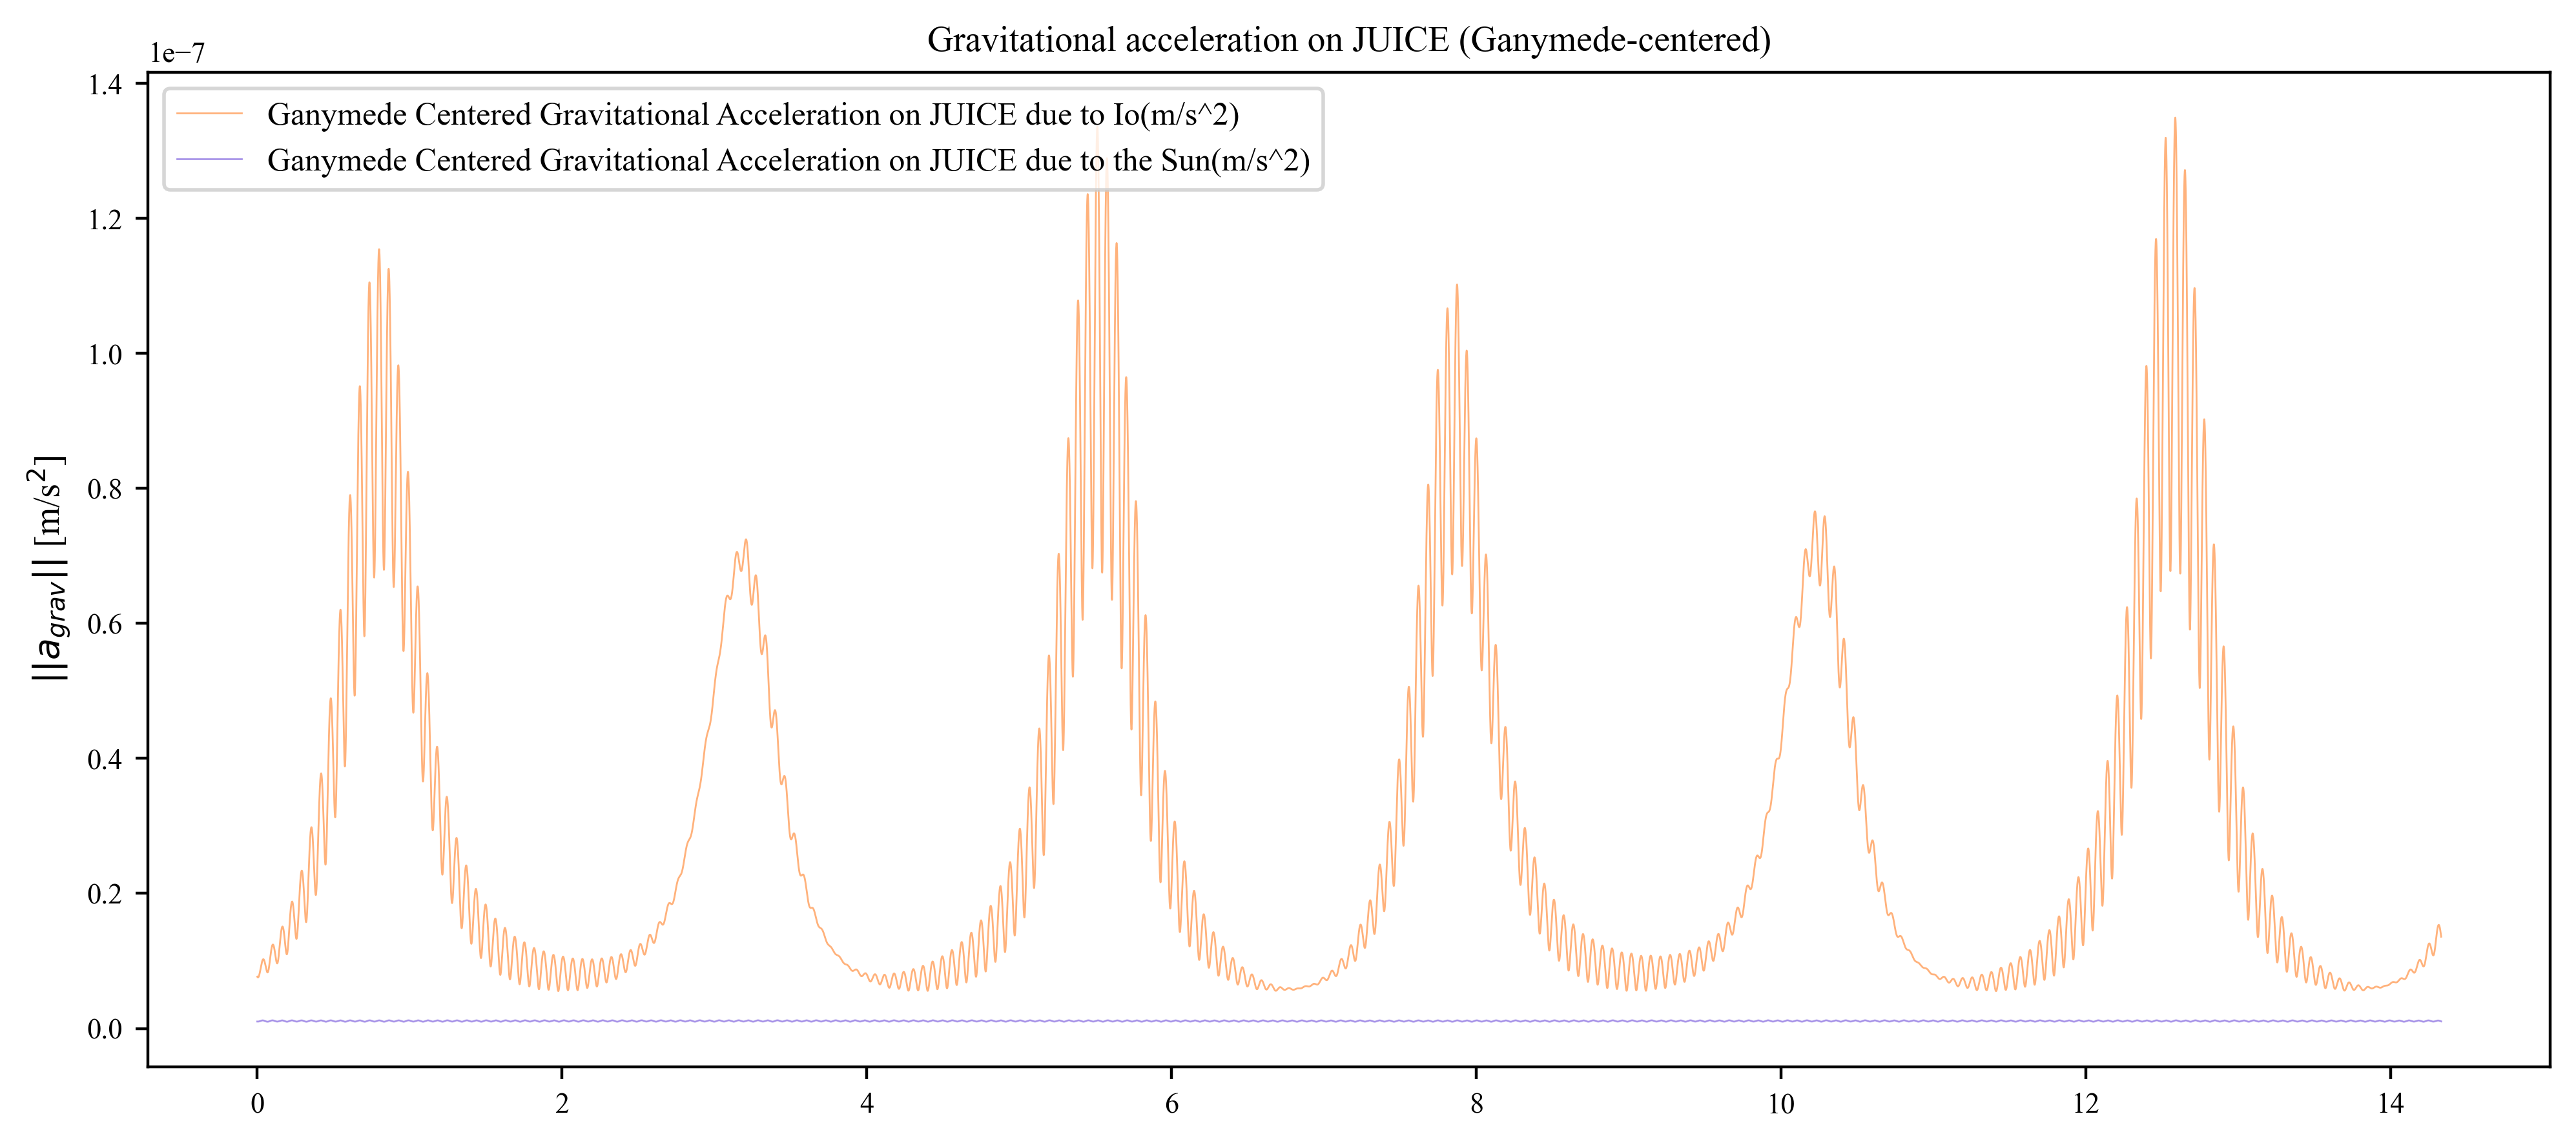

In [29]:

plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Io, axis=1),label="Ganymede Centered Gravitational Acceleration on JUICE due to Io(m/s^2)", linewidth=0.5, color = palette['pastel_orange'])
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Sun, axis = 1), label = "Ganymede Centered Gravitational Acceleration on JUICE due to the Sun(m/s^2)", linewidth = 0.5, color = palette['pastel_purple'])

plt.ylabel(r"$||a_{grav}||$ [m/s$^2$]")
plt.title("Gravitational acceleration on JUICE (Ganymede-centered)")
plt.legend()






<small> ii. In the acceleration behavior, you will see a superposition of a number of (quasi-)periodic variations. For both the acceleration
exerted by Io and the acceleration exerted by the Sun, identify the
(quasi-)periodic variation in the acceleration that has the largest
amplitude. State the periods Tmax,Io and Tmax,Sun of these varia
tion (in hours). You are free to make this identification ‘visually’,
or in some other manner you are familiar with (such as an FFT).
But, in each case, give a clear description </small>

In [ ]:
# Fast Fourier Transform
# pipeline: transform from fn of time --> to fn of frequency --> T = 1/f --> convert to hrs

# NOTE: rfft is used instead of fft to simplify the extraction of positive terms

# Detrend --> remove the mean
a_dash_Io = np.linalg.norm(grav_acc_JUICE_Io, axis = 1) - np.mean(np.linalg.norm(grav_acc_JUICE_Io, axis = 1))
a_dash_Sun = np.linalg.norm(grav_acc_JUICE_Sun, axis = 1) - np.mean(np.linalg.norm(grav_acc_JUICE_Sun, axis = 1))

# Computing the complex spectrum and finding its norm --> Amplitude
A_Io = np.abs(np.fft.rfft(a_dash_Io))
A_Sun = np.abs(np.fft.rfft(a_dash_Sun))

# Computing frequency bins
f_Io = np.fft.rfftfreq(len(a_dash_Io), d = fixed_step_size)
f_Sun = np.fft.rfftfreq(len(a_dash_Sun), d = fixed_step_size)

# Obtaining the max freq value
f_Io_max = f_Io[np.argmax(A_Io[1:])+1]
f_Sun_max = f_Sun[np.argmax(A_Sun[1:])+1]

# NOTE: np.fft.rfft() returns [DC freq, positive freq..], so we must remove the first term before finding the index

# Computing the time period in hrs
T_Io_max = (1 / f_Io_max) / 3600.0
T_Sun_max = (1 / f_Sun_max) / 3600.0
print(T_Io_max)
print(T_Sun_max)
# Results:
#   57.333796296296285
#   1.5289012345679014


57.333796296296285
1.5289012345679014


C:\Users\reiar\AppData\Local\Temp\ipykernel_32860\2454881091.py:1: RuntimeWarning: divide by zero encountered in divide
  T_Io = (1/f_Io)/ 3600.0
C:\Users\reiar\AppData\Local\Temp\ipykernel_32860\2454881091.py:2: RuntimeWarning: divide by zero encountered in divide
  T_Sun = (1/f_Sun)/ 3600.0


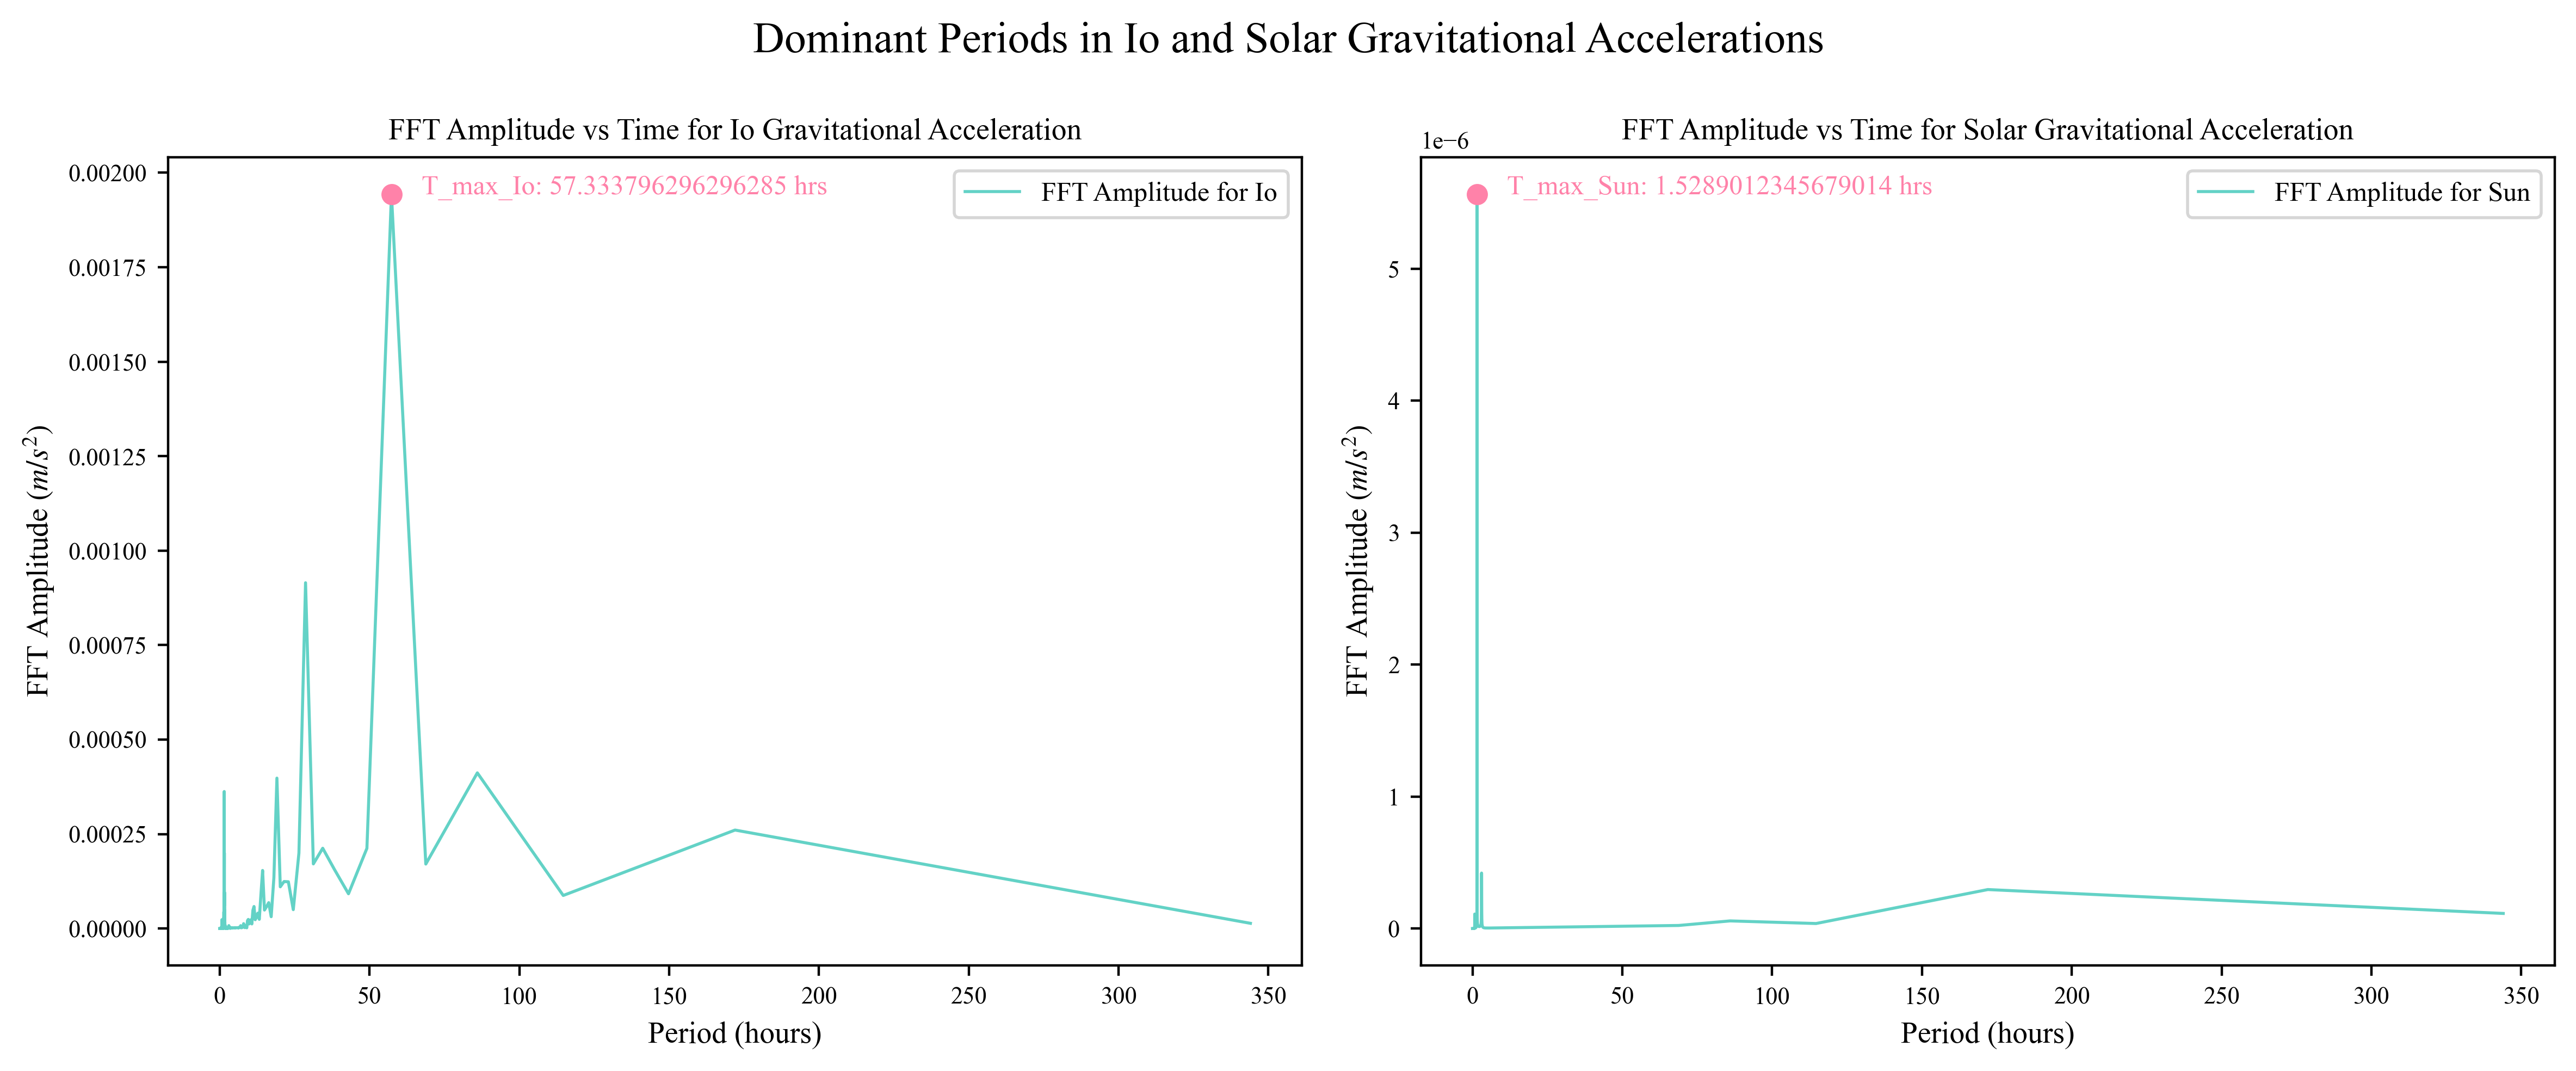

In [169]:
T_Io = (1/f_Io)/ 3600.0
T_Sun = (1/f_Sun)/ 3600.0

Io_max_pt = A_Io[np.argmax(A_Io[1:])+1]
Sun_max_pt = A_Sun[np.argmax(A_Sun[1:])+1]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=400)
ax[0].plot(T_Io, A_Io, label = "FFT Amplitude for Io", linewidth = 1, color = palette["pastel_teal"])
ax[0].plot(T_Io_max, Io_max_pt, marker = 'o', color = palette["pastel_pink"])
ax[0].text(T_Io_max  + 10 ,Io_max_pt, f"T_max_Io: {T_Io_max} hrs", color=palette["pastel_pink"], fontsize=9)
ax[0].set_xlabel("Period (hours)")
ax[0].set_ylabel(r"FFT Amplitude $(m/s^2)$")
ax[0].set_title('FFT Amplitude vs Time for Io Gravitational Acceleration')
ax[0].legend()

ax[1].plot(T_Sun, A_Sun, label = "FFT Amplitude for Sun", linewidth = 1, color = palette["pastel_teal"])
ax[1].plot(T_Sun_max, Sun_max_pt , marker = 'o', color = palette["pastel_pink"])
ax[1].text(T_Sun_max + 10, Sun_max_pt, f"T_max_Sun: {T_Sun_max} hrs", color=palette["pastel_pink"], fontsize=9)
ax[1].set_xlabel("Period (hours)")
ax[1].set_ylabel(r"FFT Amplitude $(m/s^2)$")
ax[1].legend()
ax[1].set_title('FFT Amplitude vs Time for Solar Gravitational Acceleration')

fig.suptitle("Dominant Periods in Io and Solar Gravitational Accelerations")
plt.tight_layout()
plt.show()




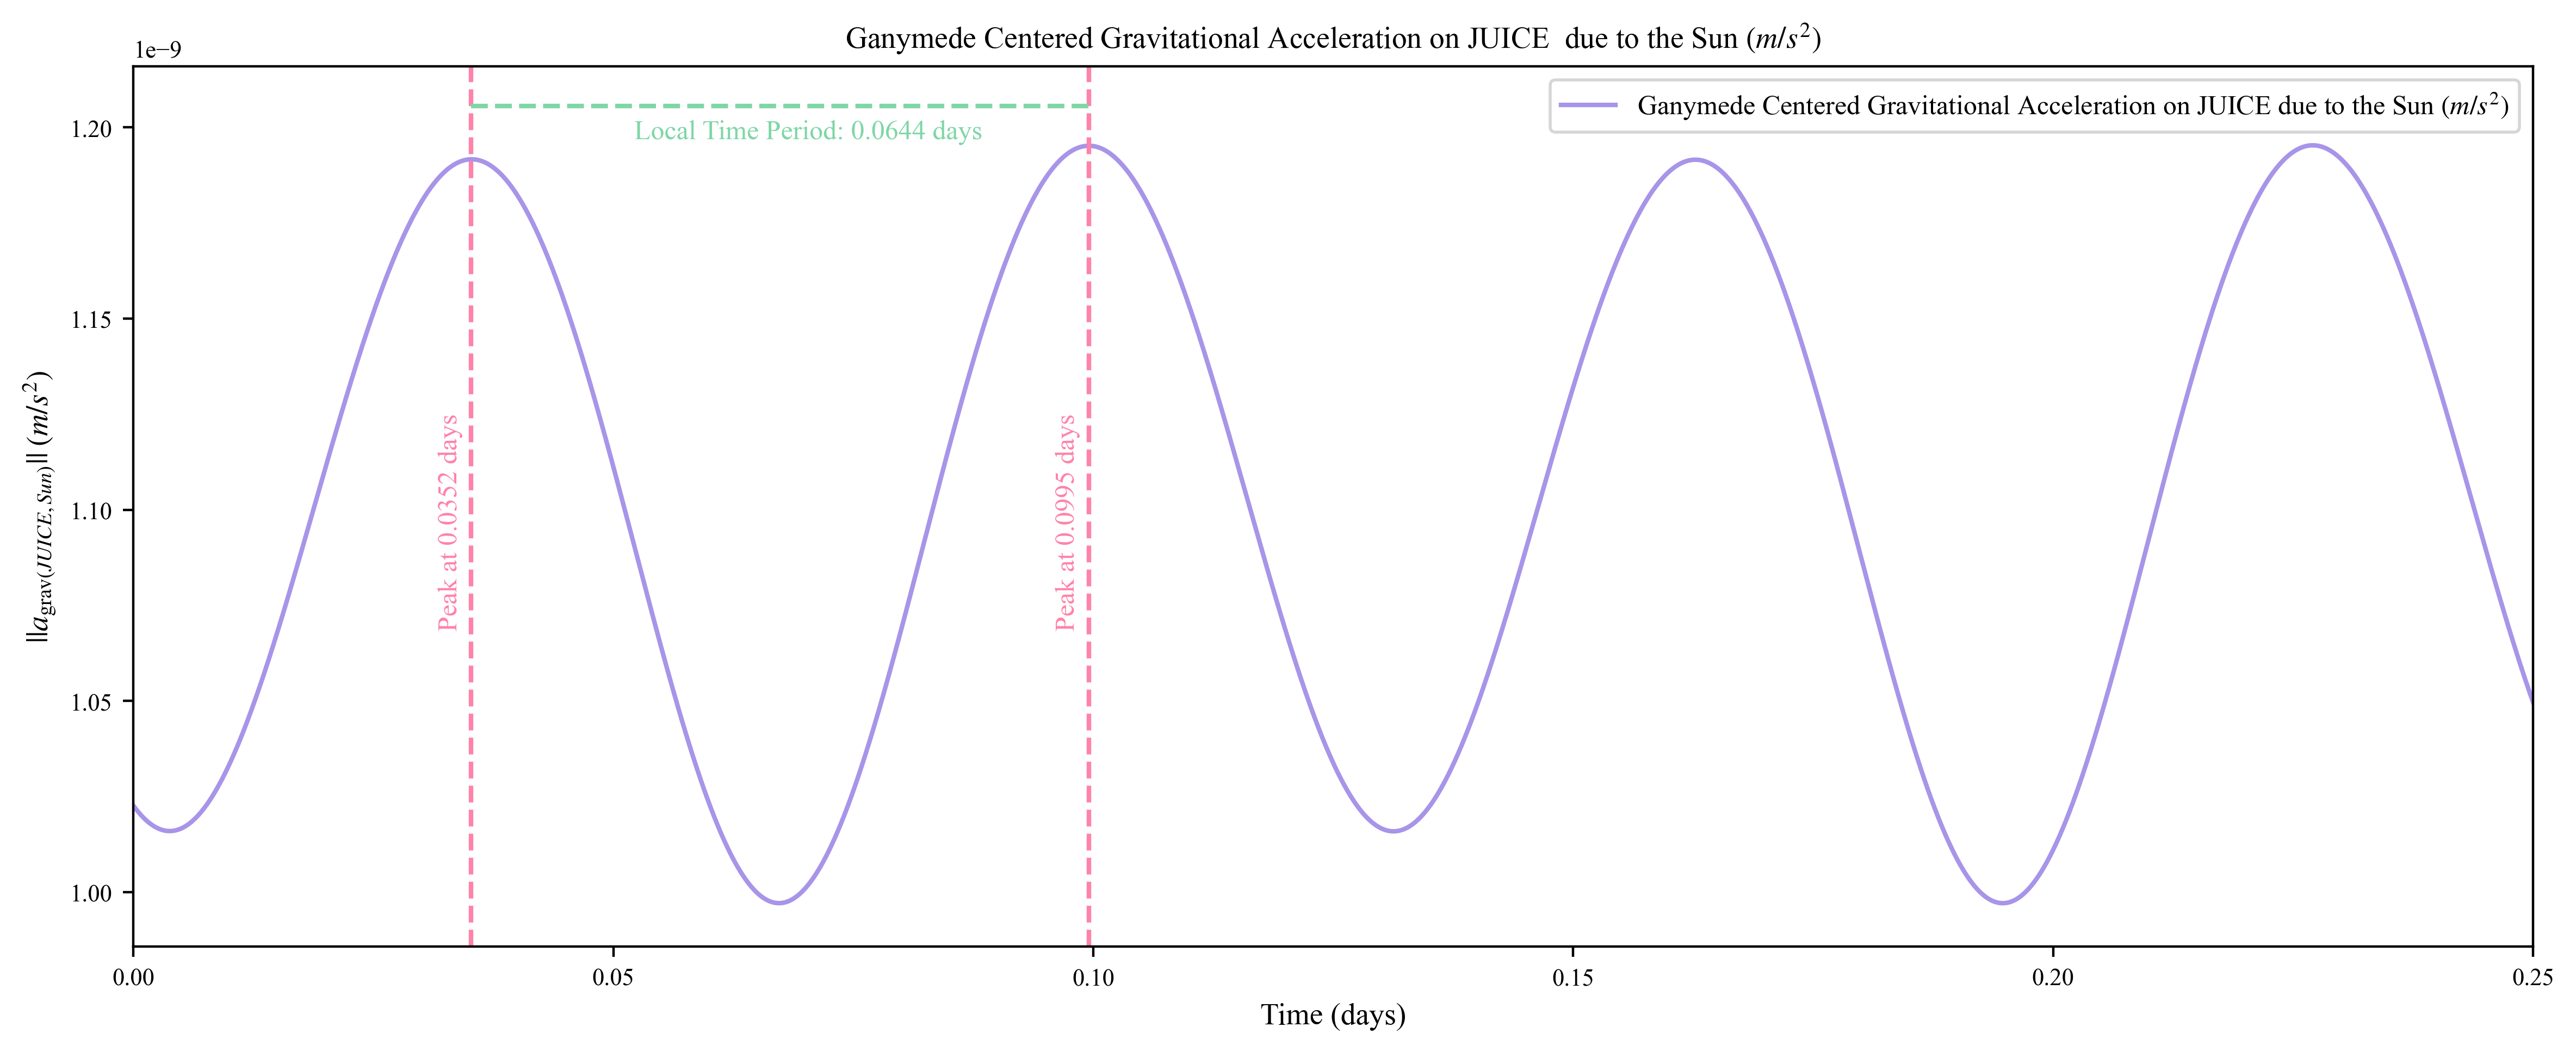

In [ ]:
from scipy.signal import find_peaks

y_Sun = np.linalg.norm(grav_acc_JUICE_Sun, axis = 1)
peaks, _ = find_peaks(y_Sun)



plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, y_Sun, label = r"Ganymede Centered Gravitational Acceleration on JUICE due to the Sun $(m/s^2)$", linewidth = 1.5, color = palette['pastel_purple'])
plt.xlabel("Time (days)")
plt.xlim(0,0.25)
plt.axvline(x = time_days[peaks[0]], color = palette['pastel_pink'], linestyle = '--')
plt.axvline(x = time_days[peaks[1]], color = palette['pastel_pink'], linestyle = '--')
plt.hlines(y = np.max(y_Sun), xmin = time_days[peaks[0]], xmax = time_days[peaks[1]], colors = palette['pastel_green'], linestyles = '--')
plt.text(time_days[peaks[0]] - 0.0035, 1.07e-9, f"Peak at {time_days[peaks[0]]:.4f} days", color=palette['pastel_pink'], fontsize=9, rotation = 90)
plt.text(time_days[peaks[1]] - 0.0035, 1.07e-9, f"Peak at {time_days[peaks[1]]:.4f} days", color=palette['pastel_pink'], fontsize=9, rotation = 90)
plt.text(time_days[peaks[0]] + 0.017, 1.197e-9, f"Local Time Period: {time_days[peaks[1]] - time_days[peaks[0]]:.4f} days ", color=palette['pastel_green'], fontsize=9)
plt.ylabel(r"$||a_{\mathrm{grav}(JUICE,Sun)}|| \; (m/s^{2})$")
plt.legend(loc = 'upper right')
plt.title(r"Ganymede Centered Gravitational Acceleration on JUICE  due to the Sun $(m/s^2)$")
plt.tight_layout()
plt.show()




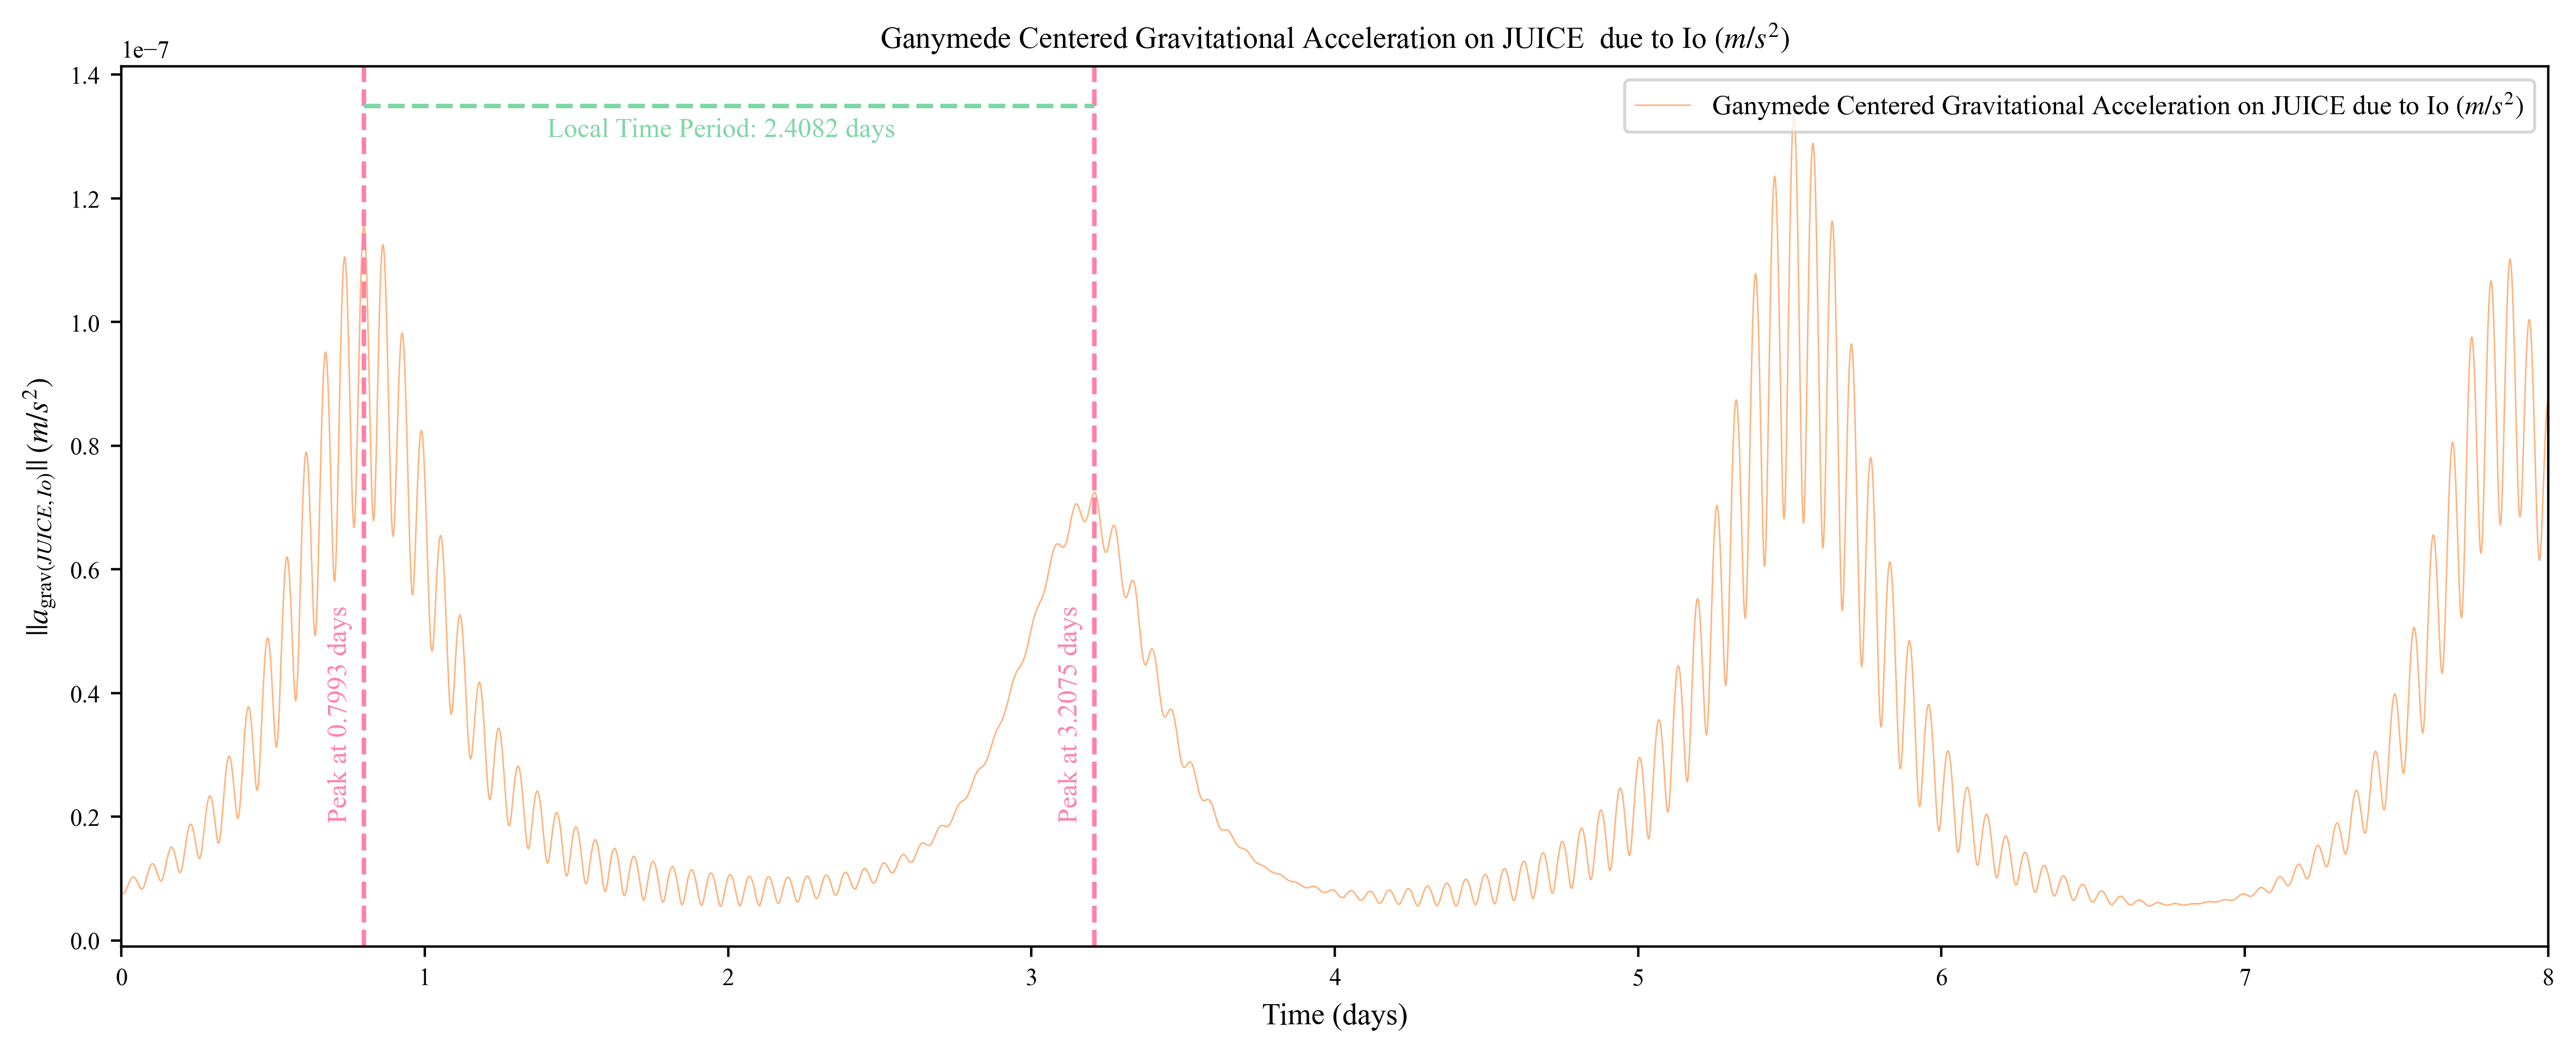

In [156]:
# Plot
y_Io = np.linalg.norm(grav_acc_JUICE_Io, axis = 1)
peaks, _ = find_peaks(y_Io)

plt.figure(figsize = (12,5), dpi = 400)
plt.plot(time_days, np.linalg.norm(grav_acc_JUICE_Io, axis = 1), label = r"Ganymede Centered Gravitational Acceleration on JUICE due to Io $(m/s^2)$", linewidth = 0.5, color = palette['pastel_orange'])
plt.xlabel("Time (days)")
plt.xlim(0,8)
plt.ylabel(r"$||a_{\mathrm{grav}(JUICE,Io)}|| \; (m/s^{2})$")
plt.axvline(x = time_days[peaks[12]], color = palette["pastel_pink"], linestyle = "--")
plt.axvline(x = time_days[peaks[45]], color = palette["pastel_pink"], linestyle = "--")
plt.hlines(y = np.max(y_Io), xmin = time_days[peaks[12]], xmax = time_days[peaks[45]], colors = palette['pastel_green'], linestyles = '--')
plt.text(time_days[peaks[12]] - 0.12, 0.2e-7, f"Peak at {time_days[peaks[12]]:.4f} days", color=palette['pastel_pink'], fontsize=9, rotation = 90)
plt.text(time_days[peaks[45]] - 0.12, 0.2e-7, f"Peak at {time_days[peaks[45]]:.4f} days", color=palette['pastel_pink'], fontsize=9, rotation = 90)
plt.text((time_days[peaks[45]] - time_days[peaks[12]])/2 +0.2, 1.3e-7, f"Local Time Period: {time_days[peaks[45]] - time_days[peaks[12]]:.4f} days ", color=palette['pastel_green'], fontsize=9)
plt.title(r"Ganymede Centered Gravitational Acceleration on JUICE  due to Io $(m/s^2)$")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()